<div style="width: 100%; clear: both;">
<div style="float: left; width: 50%;">
<img src="http://www.uoc.edu/portal/_resources/common/imatges/marca_UOC/UOC_Masterbrand.jpg" align="left">
</div>
<div style="float: right; width: 50%;">
<p style="margin: 0; padding-top: 22px; text-align:right;">Supervivencia en Cáncer de Mama y Pulmón</p>
<p style="margin: 0; text-align:right;">2026-1 · Máster universitario en Ciencia de datos (Data science)</p>
<p style="margin: 0; text-align:right; padding-button: 100px;">Estudios de Informática, Multimedia y Telecomunicación</p>
<p style="margin: 0; text-align:right;">Julio Úbeda Quesada</p>
</div>
</div>
<div style="width:100%;">&nbsp;</div>

<div class="alert alert-block alert-info">
<strong>Nombre y apellidos: JULIO ÚBEDA QUESADA</strong>
</div>

# Análisis Exploratorio de Datos (EDA) Clínicos 

Este *notebook* contiene el Análisis Exploratorio de Datos (EDA) para conjuntos de datos clínicos referentes al cáncer de mama y de pulmón. El objetivo de esta fase es comprender la estructura de las variables, evaluar la calidad de los datos (valores nulos, distribuciones) y explorar las variables objetivo fundamentales para el análisis de supervivencia.

Para la correcta ejecución del cuaderno necesitaremos importar los siguientes módulos:

In [1]:
# Proporciona funciones para interactuar con el sistema operativo (como rutas de archivos).
import os  

# Permite modificar aspectos del entorno de ejecución de Python, como la lista de rutas de búsqueda de módulos (sys.path).
import sys 

# En notebooks, usa la ruta del notebook actual
root_dir = os.path.abspath('..')  # Sube un nivel desde /notebooks/
sys.path.append(root_dir)

# Importación de librerías necesarias
# Importa las bibliotecas necesarias para el análisis de datos y visualización.
import pandas as pd

# Mostrar todas las filas que necesites (por ejemplo 200)
pd.set_option('display.max_rows', 200)

# Mostrar todas las columnas sin cortar
pd.set_option('display.max_columns', None)

# Evitar que las columnas se corten en ancho
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

import numpy as np
import os
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings


warnings.filterwarnings('ignore')

In [27]:
# Importa y actualiza las funciones personalizadas desde utils.
import importlib
import utils.EDA_functions as eda
importlib.reload(eda)

<module 'utils.EDA_functions' from 'c:\\Users\\jubeda2\\Documents\\GitHub\\TFM---Analisis-de-supervivencia-del-cancer\\Modulo 3 - Diseño e implementacion del trabajo\\utils\\EDA_functions.py'>

# 1. Estrategia de Adquisición de datos de cáncer de mama y de pulmón

Para evitar lidiar con la complejidad de la API de GDC o las dependencias de R (`TCGAbiolinks`), extraeremos los datos curados directamente desde el *Datahub* público de [cBioPortal Datasets](https://www.cbioportal.org/datasets). 

Los identificadores de los estudios son:

* **METABRIC (Cáncer de mama):** `brca_metabric_clinical_data`: 
  * C:\Users\usuario\Documents\GitHub\TFM---Analisis-de-supervivencia-del-cancer\Modulo 3 - Diseño e implementacion del trabajo\data\brca_metabric_clinical_data.tsv
* **TCGA-BRCA (Cáncer de mama):** `brca_tcga_gdc_clinical_data` 
  * C:\Users\usuario\Documents\GitHub\TFM---Analisis-de-supervivencia-del-cancer\Modulo 3 - Diseño e implementacion del trabajo\data\brca_tcga_gdc_clinical_data.tsv
* **TCGA-LUAD (Adenocarcinoma de pulmón):** `nsclc_ctdx_msk_2022_clinical_data`
* **TCGA-LUSC (Carcinoma escamoso de pulmón):** `nsclc_ctdx_msk_2022_clinical_data`
  * C:\Users\usuario\Documents\GitHub\TFM---Analisis-de-supervivencia-del-cancer\Modulo 3 - Diseño e implementacion del trabajo\data\nsclc_ctdx_msk_2022_clinical_data.tsv

# 2. Cargar los datos clínicos

En este apartado se realiza la carga de los datasets clínicos previamente descargados. Para ello, se emplea un enfoque automatizado que permite leer múltiples archivos en formato `.tsv` y almacenarlos en una estructura de tipo diccionario, donde cada clave corresponde al nombre del dataset y su valor asociado es un *DataFrame* de `pandas`. 

In [6]:
# Definir la lista con las rutas de tus 3 archivos .tsv
rutas_archivos = [
    r"../data/brca_metabric_clinical_data.tsv",
    r"../data/brca_tcga_gdc_clinical_data.tsv",
    r"../data/nsclc_ctdx_msk_2022_clinical_data.tsv"  
]

# Crea el diccionario vacío para almacenar los DataFrames
diccionario_datos = {}

# Bucle para importar y guardar cada archivo
for ruta in rutas_archivos:
    # Extraer el nombre base del archivo y quitarle la extensión '.tsv'
    nombre_clave = os.path.basename(ruta).replace('.tsv', '')
    
    # Leer el .tsv y asignarlo al diccionario
    diccionario_datos[nombre_clave] = pd.read_csv(ruta, sep='\t')

diccionario_datos.keys()  # Mostrar las claves para verificar que se han importado correctamente

dict_keys(['brca_metabric_clinical_data', 'brca_tcga_gdc_clinical_data', 'nsclc_ctdx_msk_2022_clinical_data'])

# **3. Breast Cancer (METABRIC, Nature 2012 & Nat Commun 2016)**

**Targeted sequencing of 2509 primary breast tumors with 548 matched normals.**

* **Enlace de descarga:** (https://www.cbioportal.org/study/summary?id=brca_metabric)
* **Papers relacionados:** Pereira et al. Nat Commun 2016, Rueda et al. Nature 2019, Curtis et al. Nature 2012.

## **3.1. Descripción  del conjunto de datos**

### **A. Dimensiones, tipos de datos y estructura general**

El conjunto de datos de la cohorte METABRIC presenta una estructura tabular clásica para estudios clínico-genómicos. Su análisis estructural revela la siguiente composición:

* **Dimensiones globales y granularidad:** 
    * El dataset consta de **2.509 registros (filas)** y **39 variables (columnas)**. 
    * Presenta una **relación estricta de 1:1** entre sujetos y muestras biológicas. Es decir, el conjunto de datos está compuesto por 2.509 pacientes únicos que aportan exactamente una muestra de tumor primario cada uno (`Number of Samples Per Patient` = 1).
  
* **Tipología de datos informáticos:**
    * **Variables numéricas (`float64`, `int64`):** Representan mediciones temporales continuas, parámetros físicos o recuentos absolutos (ej. `Age at Diagnosis`, `Tumor Size`, `Mutation Count`, `Overall Survival (Months)`).
    * **Variables categóricas y de texto (`str`, `object`):** Conforman la mayoría del dataset y recogen clasificaciones clínicas estandarizadas, estados patológicos, identificadores y variables binarias (ej. `Cancer Type Detailed`, `ER Status`, `Overall Survival Status`).

* **Composición estructural (Familias de variables):**
    * **Identificadores del estudio:** Metadatos trazables del proyecto (`Study ID`, `Patient ID`, `Sample ID`).
    * **Características Clínico-Demográficas:** Contexto del paciente en el momento del estudio (`Age at Diagnosis`, `Inferred Menopausal State`).
    * **Perfil Anatómico y Patológico:** Variables que describen físicamente la gravedad y extensión del tumor (`Tumor Stage`, `Tumor Size`, `Neoplasm Histologic Grade`, `Lymph nodes examined positive`).
    * **Perfil Molecular y Genómico:** Biomarcadores extraídos mediante secuenciación o inmunohistoquímica que definen el comportamiento biológico de la enfermedad (`ER Status`, `HER2 Status`, `Pam50 + Claudin-low subtype`, `TMB (nonsynonymous)`).
    * **Régimen de Tratamientos:** Intervenciones terapéuticas aplicadas al paciente (`Chemotherapy`, `Radio Therapy`, `Hormone Therapy`, `Type of Breast Surgery`).
    * **Variables Objetivo (Supervivencia):** Las variables dependientes críticas para el entrenamiento de los algoritmos de riesgo, separadas en supervivencia global (`Overall Survival (Months)`, `Overall Survival Status`) y riesgo de recaída (`Relapse Free Status (Months)`).

### **B. Valores nulos y completitud por familias de variables**

Analizando la completitud del conjunto de datos METABRIC, se observa que los valores nulos no se distribuyen al azar, sino que afectan a bloques de información específicos (probablemente por diferencias en los protocolos de recogida de datos a lo largo de los años). Para facilitar el preprocesamiento, se han categorizado las variables en las siguientes familias:

* **Identificadores y clasificación base (0% nulos):** Este núcleo de variables estructurales y fenotípicas generales está perfectamente completo.
    * `Study ID`, `Patient ID`, `Sample ID`, `Number of Samples Per Patient` y `Sample Type`.
    * `Sex`, `Cancer Type`, `Cancer Type Detailed` y `Oncotree Code`.
    * `TMB (nonsynonymous)` (Carga mutacional del tumor).

* **Demografía y características clínico-patológicas de alta completitud (< 11% nulos):**
    * **Demografía:** `Age at Diagnosis` y `Cohort` (ambas con solo 0.44% nulos).
    * **Histología y tamaño:** `ER Status` (1.59%), `ER status measured by IHC` (3.31%), `Neoplasm Histologic Grade` (4.82%), `Tumor Other Histologic Subtype` (5.38%) y `Tumor Size` (5.94%).
    * **Métricas de riesgo y progresión local:** `Mutation Count` (6.02%), `Nottingham prognostic index` (8.85%) y `Lymph nodes examined positive` (10.60%).

* **Variables de Tratamiento (21% - 22% nulos):**
    * `Chemotherapy` (21.08%)
    * `Hormone Therapy` (21.08%)
    * `Radio Therapy` (21.08%)
    * `Type of Breast Surgery` (22.08%)

>     Existe un bloque considerable de pacientes de los que no se tiene constancia del régimen terapéutico aplicado. En oncología clínica, un nulo en tratamiento a veces implica que no se administró, algo que deberá evaluarse con cuidado.

* **Biomarcadores Moleculares y Estado Fisiológico (21% - 30% nulos):**
    * `HER2 Status` y `HER2 status measured by SNP6` (ambas 21.08%)
    * `PR Status` (21.08%)
    * `Pam50 + Claudin-low subtype` (21.08%)
    * `Integrative Cluster` (21.08%)
    * `Inferred Menopausal State` (21.08%)
    * `3-Gene classifier subtype` (29.69%, una de las variables moleculares con más nulos)

>     Estas variables provienen de ensayos moleculares específicos (como microarrays o secuenciación dirigida) que no estuvieron disponibles para toda la cohorte.

* **Variables Anatómicas Críticas (23% - 29% nulos):**
    * `Cellularity` (23.60%)
    * `Primary Tumor Laterality` (25.47%)
    * `Tumor Stage` (28.74%). *Nota: Al ser una variable crítica para determinar la fase de la enfermedad, requerirá una estrategia de imputación robusta (ej. KNN Imputer apoyándose en el tamaño tumoral y ganglios positivos).*

* **Variables Temporales y de Eventos (Supervivencia):**
    * **Recaída (Bajos nulos):** Los datos sobre el intervalo libre de enfermedad son muy sólidos, con solo un 0.84% de nulos en `Relapse Free Status` y 4.82% en `Relapse Free Status (Months)`.
    * **Supervivencia Global (Altos nulos):** El tiempo total hasta el evento final presenta un bloque faltante idéntico, sugiriendo una pérdida de seguimiento en aproximadamente un quinto de la cohorte: `Overall Survival (Months)` (21.04%), `Overall Survival Status` (21.04%) y `Patient's Vital Status` (21.08%).

In [7]:
# Acceder al DataFrame por su clave:
brca_metabric = diccionario_datos['brca_metabric_clinical_data']
eda.describe_df(brca_metabric)

Dimensiones del DataFrame: 2509 filas, 39 columnas



,Column,Data Type,Non-null Count,% Null Values,Unique Values,TopCounts,mean,median,std,min,25%,75%,max
0,Study ID,str,2509,0.00,1,brca_metabric (2509),NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Patient ID,str,2509,0.00,2509,"MB-0000 (1), MB-0002 (1), MB-0005 (1)",NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Sample ID,str,2509,0.00,2509,"MB-0000 (1), MB-0002 (1), MB-0005 (1)",NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Age at Diagnosis,float64,2498,0.44,1843,None,60.420300,61.110000,13.032997,21.93,50.920000,70.000000,96.290000
4,Type of Breast Surgery,str,1955,22.08,2,"MASTECTOMY (1170), BREAST CONSERVING (785)",NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Cancer Type,str,2509,0.00,1,Breast Cancer (2509),NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Cancer Type Detailed,str,2509,0.00,8,"Breast Invasive Ductal Carcinoma (1865), Breast Mixed Ductal and Lobular Carcinoma (269), Breast Invasive Lobular Carcinoma (192)",NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Cellularity,str,1917,23.60,3,"High (965), Moderate (737), Low (215)",NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,Chemotherapy,str,1980,21.08,2,"NO (1568), YES (412)",NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,Pam50 + Claudin-low subtype,str,1980,21.08,7,"LumA (700), LumB (475), Her2 (224)",NaN,NaN,NaN,NaN,NaN,NaN,NaN


### **C. Análisis de Variables Categóricas: Distribución y Tendencias**

* **Identificadores y Metadatos del Estudio:**
  * **Identificadores Únicos (`Patient ID`, `Sample ID`):** Presentan una cardinalidad máxima (2.509 valores únicos), lo que confirma la ausencia de duplicados y una relación unívoca entre paciente y muestra.
  * **Variables de Varianza Cero (`Study ID`, `Cancer Type`, `Sample Type`, `Sex`):** Estas variables funcionan como constantes en METABRIC. El 100% de la muestra pertenece al estudio METABRIC, son tumores de mama (`Breast Cancer`), de tipo primario (`Primary`) y en pacientes femeninas (`Female`). Al no tener variabilidad, se excluyen del modelado pero definen el alcance de la población.

* **Perfil Clínico-Demográfico y Anatómico:**
  * **Estado Menopáusico (`Inferred Menopausal State`):** Existe una clara tendencia hacia pacientes **postmenopáusicas** (1.556 casos), lo cual es coherente con la distribución de edad observada en las variables numéricas.
  * **Lateralidad (`Primary Tumor Laterality`):** La distribución es casi simétrica entre la mama izquierda (973) y derecha (897), indicando que el origen anatómico del tumor no presenta un sesgo lateral en esta cohorte.
  * **Celularidad (`Cellularity`):** La mayoría de las muestras presentan una celularidad **Alta** (965) o **Moderada** (737), con una minoría de casos bajos (215). Esto es relevante para asegurar la calidad del material genético analizado.

* **Caracterización Histológica y Patológica:**
  * **Clasificación de la Enfermedad (`Cancer Type Detailed`, `Oncotree Code`, `Tumor Other Histologic Subtype`):** Se observa una **dominancia masiva del Carcinoma Ductal Invasivo (IDC)** (1.865 casos), que es el subtipo más común a nivel global. Los subtipos Mixto y Lobular aparecen en frecuencias mucho menores, lo que representa un reto de cardinalidad (clases minoritarias).
  * **Gravedad y Estadio (`Tumor Stage`, `Neoplasm Histologic Grade`):** Aunque codificados numéricamente, actúan como categorías ordinales. El **Estadio 2** y el **Grado 3** son las categorías modales, lo que indica una cohorte donde la enfermedad se suele detectar en fases intermedias pero con características celulares agresivas.

* **Biomarcadores Moleculares y Subtipos:**
  * **Estado de Receptores (`ER Status`, `PR Status`, `HER2 Status`):** * El perfil predominante es **ER Positivo** (1.825) y **PR Positivo** (1.040).
      * En contraste, el **HER2 Negativo** es la norma (1.733), validado consistentemente por los métodos IHC y SNP6.
  * **Clasificadores Intrínsecos (`Pam50 + Claudin-low`, `3-Gene classifier`, `Integrative Cluster`):** * En el gráfico de `Pam50`, los subtipos **Luminal A** (700) y **Luminal B** (475) son los más frecuentes, alineándose con la positividad de los receptores de estrógeno. 
      * La variable `Integrative Cluster` muestra una distribución más fragmentada en 10 grupos, capturando la heterogeneidad genómica fina de la enfermedad.

* **Intervenciones Terapéuticas:**
  * **Tratamientos Adyuvantes (`Chemotherapy`, `Hormone Therapy`, `Radio Therapy`):**
      * Existe un fuerte desbalance en **Quimioterapia** (la gran mayoría no la recibió: 1.568 vs 412).
      * La **Terapia Hormonal** (1.216 Sí) y la **Radioterapia** (1.173 Sí) son mucho más comunes, reflejando el estándar de cuidado para tumores Luminales/ER+.
  * **Procedimiento Quirúrgico (`Type of Breast Surgery`):** La tendencia se inclina ligeramente hacia la **Mastectomía** (1.170) frente a la cirugía conservadora (785).

* **Variables de Resultado (Target):**
  * **Estado de Supervivencia (`Overall Survival Status`, `Patient's Vital Status`):** Se observa una distribución informativa de eventos; aproximadamente el 58% de los pacientes fallecieron (`Decreased`), lo que proporciona suficientes datos para el análisis de riesgo.
  * **Estado de Recaída (`Relapse Free Status`):** La mayoría de las pacientes se mantuvieron libres de progresión (`0:Not Recurred`), aunque existe un volumen crítico de 1.002 eventos de recaída para el modelado.

In [24]:
eda.plot_categorical_subplots(
    df=brca_metabric,
    group_name="Variables Categoricas Objetivo",
    dataset_name="METABRIC",
    output_path="../images/EDA"
)

✔ Categorical subplots guardado en: ../images/EDA\METABRIC_cat_Variables_Categoricas_Objetivo.html


### **D. Análisis de Variables Numéricas**

* **Demografía y Contexto de la Cohorte:**
  * **`Age at Diagnosis` (Distribución Gausiana):** Es la variable con el comportamiento más cercano a una distribución normal. Muestra una madurez demográfica clara con una **media de 60.4 años**. Visualmente, el pico de moda se sitúa entre los 60 y 70 años, confirmando que es una cohorte mayoritariamente postmenopáusica, aunque la base ancha del histograma captura casos desde la juventud (21 años) hasta la longevidad extrema (96 años).
  * **`Cohort` (Discreta Multimodal):** Aunque numérica, su gráfico muestra que los datos no son continuos, sino que se agrupan en bloques. La tendencia es descendente, la gran mayoría de los datos provienen de las primeras tres cohortes de recolección, disminuyendo drásticamente en las cohortes 4 a 9.

* **Parámetros Clínico-Patológicos:**
  * **`Tumor Size` (Sesgo Positivo):** Presenta una distribución asimétrica hacia la derecha. El grueso de los tumores se concentra entre los **10 y 30 mm**, pero existe una cola larga de casos con tamaños superiores a 100 mm. Esto indica que la mayoría de los tumores son `Tumor Stage` T1/T2, pero hay casos aislados de enfermedad muy avanzada.
  * **`Lymph nodes examined positive` (Sesgo Extremo):** Visualmente, el histograma es una "pared" en el valor 0. La tendencia central es de baja afectación ganglionar, pero los valores atípicos que llegan hasta 45 ganglios positivos representan fenotipos de alta agresividad y riesgo de metástasis.
  * **`Nottingham prognostic index` (Multimodal):** A diferencia de las otras, esta variable presenta varios picos. Refleja visualmente los tres grupos de pronóstico clínico (bueno, intermedio y pobre). El pico más alto está en torno a un índice de 4, lo que sugiere un riesgo intermedio-alto predominante en la cohorte.

* **Métricas de Agresividad Molecular:**
  * **`Mutation Count` y `TMB (nonsynonymous)`:** Ambas variables son prácticamente idénticas en forma (confirmando su correlación de 1.0). La tendencia es de **baja carga mutacional** (mediana de 5). El hecho de que la gran mayoría de los casos se amontone cerca del cero indica que el cáncer de mama primario es genómicamente "estable" en comparación con otros tejidos, aunque la presencia de outliers sugiere la existencia de un subgrupo hipermutador.

* **Variables Temporales de Supervivencia (Variables Objetivo o `Targets`)**
  * **`Overall Survival (Months)` y `Relapse Free Status (Months)`:** Ambas muestran distribuciones muy similares con una base muy extensa. La frecuencia de supervivencia se mantiene relativamente alta y constante hasta los 150-200 meses, donde empieza a decaer. La cola llega hasta los **350 meses**, lo que visualmente demuestra un seguimiento clínico excepcional de casi 30 años.

* **Variables de Estructura (Varianza Cero)**
  * **`Number of Samples Per Patient`:** El histograma muestra una única barra masiva en el valor 1. Esto confirma visualmente la granularidad del dataset, un registro por paciente, eliminando la necesidad de modelos de medidas repetidas.

In [25]:
eda.plot_numerical_subplots(
    df=brca_metabric,
    group_name="Numéricas Clínicas",
    dataset_name="METABRIC",
    output_path="../images/EDA"
)

✔ Numerical subplots guardado en: ../images/EDA\METABRIC_num_subplots_Numéricas_Clínicas.html


✔ Heatmap guardado en: ../images/EDA\METABRIC_heatmap_correlaciones.png


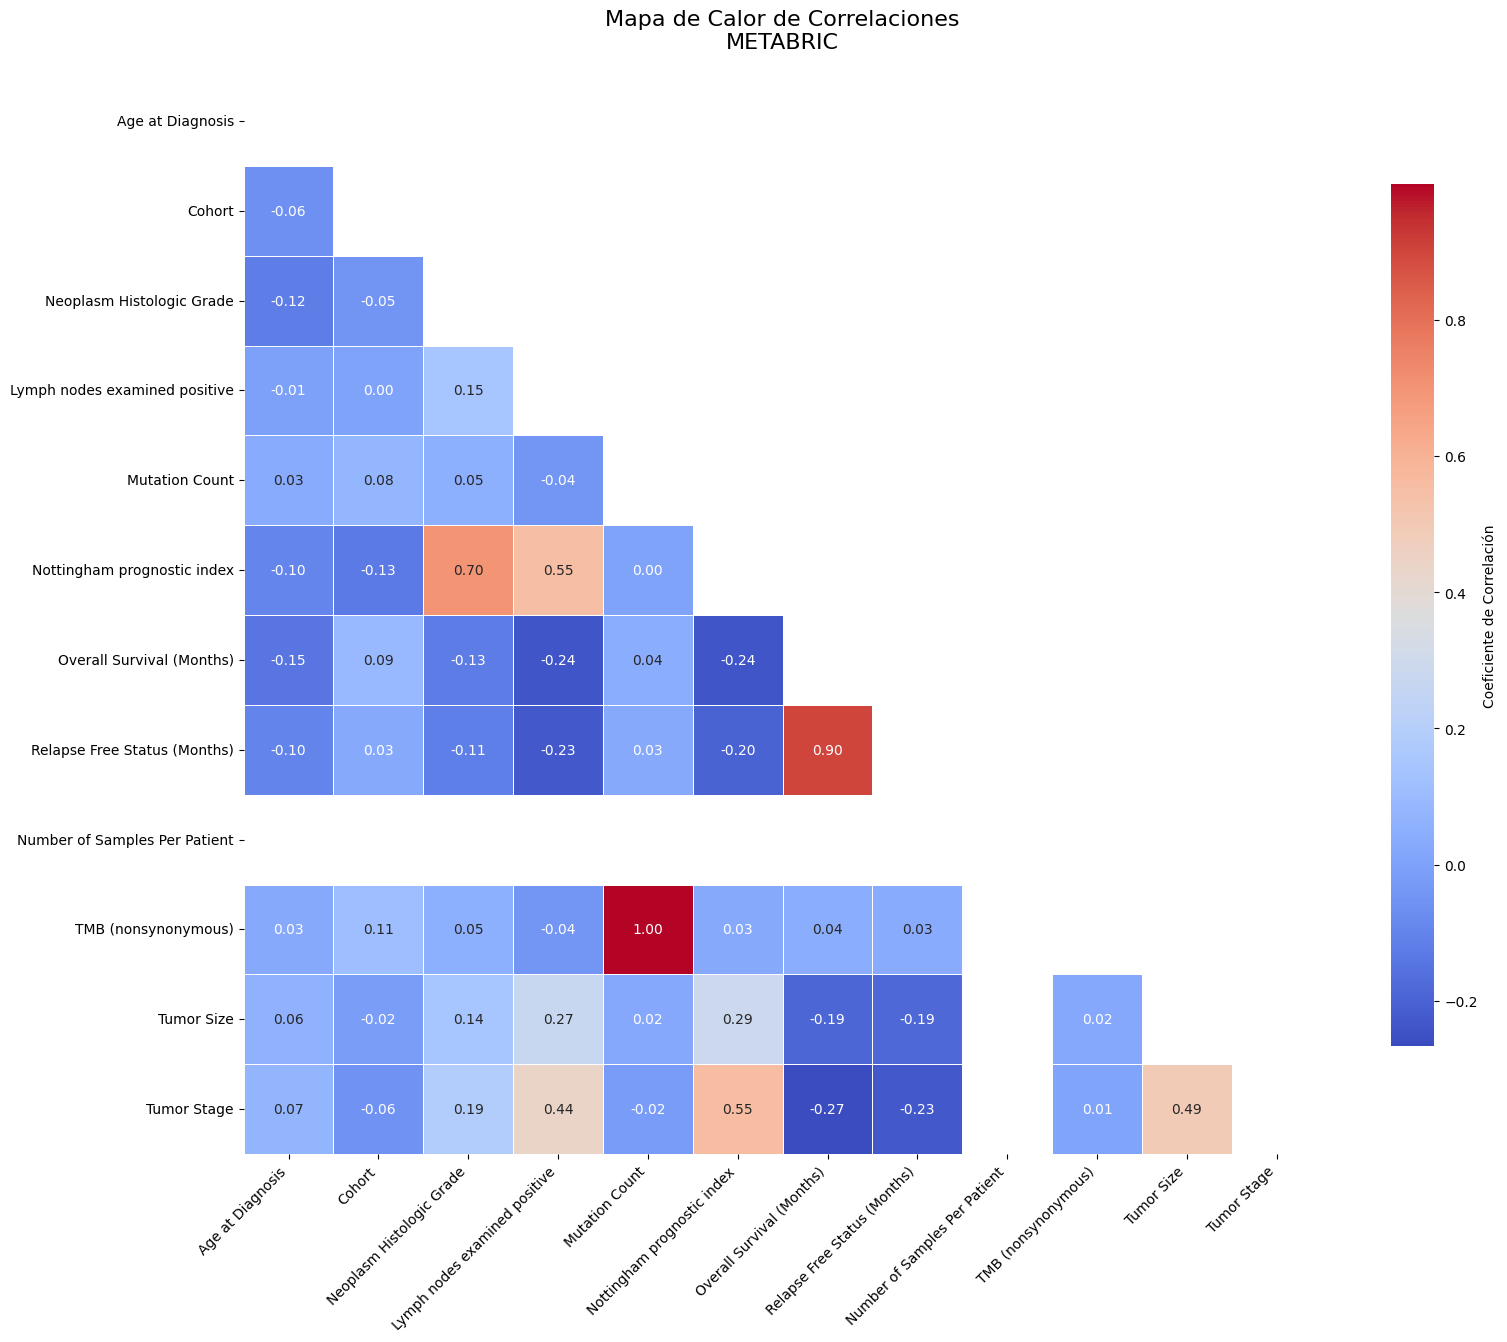


════════════════════════════════════════════════════════════════════════════════
  Resumen de Correlaciones — METABRIC (Pearson)
════════════════════════════════════════════════════════════════════════════════
  Etiqueta   Par de variables                                                  Corr
  ────────── ────────────────────────────────────────────────────────────── ───────
  ▲ Top 1    TMB (nonsynonymous)  ↔  Mutation Count                          0.9992
  ▲ Top 2    Relapse Free Status (Months)  ↔  Overall Survival (Months)      0.9023
  ▲ Top 3    Nottingham prognostic index  ↔  Neoplasm Histologic Grade       0.6997
  ▲ Top 4    Tumor Stage  ↔  Nottingham prognostic index                     0.5543
  ▲ Top 5    Nottingham prognostic index  ↔  Lymph nodes examined positive   0.5510
  ·········· ······························································ ·······
  ▼ Bot 1    Tumor Stage  ↔  Overall Survival (Months)                      -0.2666
  ▼ Bot 2    Overall Survival (Mo

In [ ]:
eda.plot_correlation_heatmap(
    df=brca_metabric[brca_metabric['']],
    dataset_name="METABRIC",
    output_path="../images/EDA"
)

## 3.3. Preprocesamiento de Datos Clínicos (Cohorte METABRIC)

Basándonos en los hallazgos del Análisis Exploratorio de Datos (EDA), en esta fase prepararemos el conjunto de datos clínicos para su posterior integración genómica y modelado predictivo. Este proceso consta de dos etapas fundamentales:

**1. Eliminación de variables no informativas:**
Como se evidenció en la distribución de cardinalidad, ciertas variables no aportan valor discriminativo al modelo predictivo y deben ser descartadas:
* **Identificadores y redundancias:** Se eliminan `Study ID`, `Sample ID` y `Number of Samples Per Patient`. Se conserva únicamente `Patient ID` como índice para el futuro cruce con los datos genómicos.
* **Variables de varianza cero:** Columnas como `Sex` (100% Female), `Cancer Type` (100% Breast Cancer) y `Sample Type` (100% Primary) se eliminan al ser constantes.

**2. Tratamiento e Imputación de Valores Nulos:**
Los modelos de supervivencia como RSF o redes neuronales requieren matrices completas. Las estrategias adoptadas son:
* **Variables Categóricas Clínicas y de Tratamiento:** Columnas como `Tumor Stage`, `Chemotherapy` o `HER2 Status` presentan un ~21-28% de nulos. Para no introducir sesgos artificiales inventando el estadio tumoral o un tratamiento, estos nulos se rellenarán con la categoría explícita `'Unknown'`. En la práctica clínica, la ausencia de esta información es en sí misma un rasgo (posiblemente pacientes que no fueron operados o medidos).
* **Variables Numéricas:** Las pocas variables numéricas con nulos (ej. `Tumor Size` o `Mutation Count`) se imputarán utilizando la **mediana**, dada la asimetría observada en sus distribuciones (presencia de valores atípicos que distorsionarían la media).
* **Variables Objetivo (Target):** Los pacientes sin datos en la variable de supervivencia (`Overall Survival (Months)` o `Overall Survival Status`) serán **eliminados** del estudio, ya que no se puede entrenar un modelo de supervivencia sin la variable a predecir.

El objetivo final es entrenar modelos de supervivencia (como Random Survival Forest o DeepSurv), estos algoritmos matemáticos no toleran valores nulos (NaN) ni variables de texto crudo. Por lo tanto, debemos transformar nuestro dataset clínico en una matriz limpia.

Viendo las distribuciones y la naturaleza de los datos, esta es mi recomendación técnica:

1.  **Tratar como Categóricas (Ordinales):** * `Tumor Stage` y `Neoplasm Histologic Grade`. Aunque son números, la diferencia entre grado 1 y 2 no es una unidad física real, sino un cambio de estado cualitativo.
    * `Cohort`. Es un identificador de grupo, no una magnitud.

2.  **Tratar como Categóricas (Nominales/Dummies):**
    * Todas las variables binarias de tratamiento (`Chemotherapy`, etc.) y receptores (`ER Status`, etc.).
    * `Pam50`, `Integrative Cluster` y `Cancer Type Detailed`. Estas requieren *One-Hot Encoding* debido a su alta cardinalidad y falta de orden intrínseco.

3.  **Mantener como Numéricas:**
    * Únicamente aquellas que representen medidas físicas reales (Edad, Tamaño, Tiempo, Conteo de ganglios o mutaciones).



### **Recomendación de Tratamiento: ¿Numéricas o Categorizadas?**

Tras analizar la forma de estas distribuciones, mi recomendación para tu preprocesamiento es:

1.  **Tratamiento de Sesgo (Transformación Log):**
    * **`Mutation Count`, `TMB`, `Tumor Size`** y **`Lymph nodes positive`** deberían pasar por una transformación de tipo $log(x + 1)$. Al tener una cola tan larga a la derecha, el logaritmo ayudará a que los modelos (especialmente los lineales o Cox) no se vean arrastrados por los valores extremos.
2.  **Variables que deberían ser Categóricas (Ordinales):**
    * **`Tumor Stage`** y **`Neoplasm Histologic Grade`**: Viendo sus histogramas, son claramente discretos y limitados (1, 2, 3, 4). Tratarlos como numéricos continuos puede inducir a error (no existe un estadio 1.5). Es mejor usarlas como categorías ordenadas.
    * **`Cohort`**: Debe ser categórica nominal. No hay una razón aritmética para que la cohorte 5 sea "superior" a la 2.
3.  **Variables para Escalado Estándar:**
    * **`Age at Diagnosis`** y el **`Nottingham prognostic index`**: Al ser más cercanas a la normalidad o tener rangos definidos, un escalado estándar (StandardScaler) para que tengan media 0 y varianza 1 será suficiente para optimizar los algoritmos.

¿Pasamos ahora al **Análisis de Correlaciones** para ver cómo se relacionan estas numéricas entre sí?

## 3.2. Selección de variables de intéres


| Variable | Breve descripción | Ejemplos |
| :--- | :--- | :--- |
| `Patient ID` | Identificador único del paciente en el estudio. | MB-0000, MB-0002, MB-0005 |
| `Age at Diagnosis` | Edad del paciente en el momento del diagnóstico (años). | 60.4, 45.2, 81.0 |
| `Tumor Stage` | Estadio patológico del tumor (escala clínica general). | 1.0, 2.0, 4.0 |
| `Cancer Type Detailed` | Subtipo histológico detallado del cáncer de mama. | Breast Invasive Ductal Carcinoma |
| `ER Status` | Estado del receptor de estrógeno (Positivo/Negativo). | Positive, Negative |
| `Pam50 + Claudin-low subtype` | Subtipo molecular intrínseco del tumor. | LumA, LumB, Her2, Basal |
| `Mutation Count` | Recuento absoluto de mutaciones detectadas. | 1.0, 5.0, 81.0 |
| `Overall Survival (Months)` | Tiempo de supervivencia global en meses (variable tiempo). | 0.0, 116.4, 355.2 |
| `Overall Survival Status` | Estado vital del paciente (variable evento/censura). | 1:DECEASED, 0:LIVING |

## 3.3. Verificacion e imputacion de *missing values*

En el conjunto de datos, se identificaron algunos valores faltantes, principalmente debido a códigos de calle ausentes o inválidos en el dataset `aemet`. Para garantizar la integridad de los datos y evitar la pérdida innecesaria de registros, se aplicaron imputaciones específicas según la naturaleza de cada variable:

* Justificación de las imputaciones:

| Columna         | % Nulos | Justificación                                                                                                                                                       | Valor imputado |
| --------------- | ------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------- | -------------- |
| **`prec`**      | 0.14%   | La precipitación (`prec`) mide mm de lluvia en el día. Cuando no se registra el valor, es razonable asumir que fue **0.0 mm** (sin lluvia).                         | `0.0`          |
| **`horatmin`**  | 0.34%   | Indica la hora de la temperatura mínima. Si falta, no tiene impacto en modelos y puede sustituirse por un valor simbólico como `"Desconocido"` (evita eliminar filas). | `"Desconocido"`   |
| **`dir`**       | 0.19%   | Dirección del viento en grados. El promedio o el valor más frecuente son buenos sustitutos. Aquí usamos la **media** porque es numérica y continua.                 | `media()`      |
| **`racha`**     | 0.19%   | Velocidad máxima del viento (km/h). Usar la **media** es razonable para mantener coherencia física sin sesgo.                                                       | `media()`      |
| **`horaracha`** | 0.19%   | Hora en la que ocurrió la racha máxima. No influye directamente en la gravedad del accidente, por lo que se puede imputar `"Desconocido"`.                             | `"Desconocido"`   |
| **`prec_cat`**  | 0.14%   | Categoría de precipitación. Si `prec = 0.0`, se asume `"sin_lluvia"`. Consistencia entre variables.                                                                 | `"sin_lluvia"` |

### 3.2.2. Variables numéricas: 

In [23]:
# 1. Extraer automáticamente todas las variables numéricas (int64, float64)
cols_num_todas = brca_metabric.select_dtypes(include=[np.number]).columns.tolist()

# 2. Filtrado de seguridad: Omitir columnas numéricas que estén 100% vacías
cols_num_validas = [col for col in cols_num_todas if brca_metabric[col].notna().sum() > 0]

# 3. Llamar a la función
eda.plot_numerical_subplots(
    df=brca_metabric, 
    columns=cols_num_validas, 
    group_name="Distribución Global", 
    dataset_name="METABRIC"
)

Se van a graficar 12 variables numéricas.


## 4. Invasive Breast Carcinoma (TCGA GDC, 2025)

**TCGA Invasive Breast Carcinoma. Source data from NCI GDC and generated in Aug 2025 using Cancer Data Aggregator.**
* Enlaze de descarga: (https://www.cbioportal.org/study/clinicalData?id=brca_tcga_gdc)
* Papers relacionados: No aparecen en el portal.

#### A. Dimensiones y tipo de datos
* El dataset tiene **1.102 filas** y **44 columnas**.
* Combina variables **numéricas** (`float64`, `int64`) y **categóricas/booleanas** (`str`, `object`).
* Existen **1.095 pacientes únicos** para 1.102 muestras, indicando que una pequeña fracción de pacientes aporta más de una muestra (ej. tumor primario y metástasis).
* Rica presencia de códigos clínicos internacionales (`ICD-10 Classification`, `AJCC Pathologic Stage`).

#### B. Valores nulos
* Destaca por su **altísima calidad y completitud** estructural en comparación con METABRIC. La inmensa mayoría de las columnas tienen 0% o <1% de nulos.
* Las únicas variables con porcentaje de nulos digno de atención son:
  * `Ethnicity Category`: 15.8% nulos
  * `Disease Free (Months)` y `Disease Free Status`: ~14.4% nulos
  * `Mutation Count` y `TMB`: ~11.9% nulos

#### C. Distribución de valores y cardinalidad
* **Supervivencia y censura (Muy importante para los modelos):**
  * Elevado desbalance en el estado vital (947 `LIVING` vs 154 `DECEASED`), lo que significa una altísima tasa de censura.
  * El seguimiento es corto: la mediana de `Overall Survival (Months)` es de apenas 26.9 meses.
* **Genómica:**
  * `Mutation Count` reporta una media de 69 mutaciones, con casos extremos (outliers) de hasta 4.784 mutaciones, indicando perfiles hipermutados que no se veían en METABRIC.
* **Estadificación:**
  * Dominancia de estadios iniciales e intermedios (`Stage IIA`: 358, `Stage IIB`: 260).

#### D. Diccionario de variables clave (TCGA-BRCA)

| Variable | Breve descripción | Ejemplos |
| :--- | :--- | :--- |
| `Sample ID` | Identificador único de la muestra biológica. | TCGA-3C-AAAU-01 |
| `Diagnosis Age` | Edad del paciente al momento del diagnóstico. | 58.0, 49.0, 89.0 |
| `AJCC Pathologic Stage` | Estadio patológico según los criterios del comité AJCC. | Stage IIA, Stage IIIA |
| `Fraction Genome Altered` | Proporción del genoma que presenta alteraciones. | 0.0, 0.258, 0.997 |
| `Mutation Count` | Recuento total de mutaciones en la muestra. | 33.0, 69.0, 4784.0 |
| `Disease Free (Months)` | Tiempo en meses hasta la recurrencia o progresión. | 0.0, 25.0, 281.2 |
| `Overall Survival (Months)` | Tiempo de seguimiento total desde el diagnóstico. | 14.4, 40.3, 282.6 |
| `Overall Survival Status` | Estado vital del paciente (0 vivo, 1 fallecido). | 0:LIVING, 1:DECEASED |

In [5]:
# Para acceder a un DataFrame específico después, solo tienes que llamarlo por su clave:
brca_tcga_gdc = diccionario_datos['brca_tcga_gdc_clinical_data']
eda.describe_df(brca_tcga_gdc)

Dimensiones del DataFrame: 1102 filas, 44 columnas



,Column,Data Type,Non-null Count,% Null Values,Unique Values,TopCounts,mean,median,std,min,25%,75%,max
0,Study ID,str,1102,0.00,1,brca_tcga_gdc (1102),NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Patient ID,str,1102,0.00,1095,"TCGA-AC-A6IX (2), TCGA-BH-A18V (2), TCGA-BH-A1ES (2)",NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Sample ID,str,1102,0.00,1102,"TCGA-3C-AAAU-01 (1), TCGA-3C-AALI-01 (1), TCGA-3C-AALJ-01 (1)",NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Diagnosis Age,float64,1086,1.45,64,None,58.507366,58.000000,13.213993,26.000000,49.000000,68.000000,89.000000
4,American Joint Committee on Cancer Publication Version Type,str,960,12.89,5,"6th (445), 7th (419), 5th (59)",NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Biopsy Site,str,1101,0.09,1,Breast (1101),NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Cancer Type,str,1102,0.00,1,Invasive Breast Carcinoma (1102),NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Cancer Type Detailed,str,1102,0.00,1,Invasive Breast Carcinoma (1102),NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,Last Communication Contact from Initial Pathologic Diagnosis Date,float64,994,9.80,647,None,721.242455,359.000000,972.922774,-7.000000,100.250000,1013.000000,7067.000000
9,Birth from Initial Pathologic Diagnosis Date,float64,1086,1.45,1042,None,-21558.522099,-21527.000000,4827.882673,-32873.000000,-24847.750000,-18005.000000,-9706.000000


## 4.2 Análisis exploratorio de variables

### 4.2.1. Variables categóricas: 

### 4.2.2. Variables numéricas: 



# 5. Metastatic Non-Small Cell Lung Cancer (MSK, Nature Medicine 2022)

**Targeted sequencing of ctDNA samples drawn from patients with metastatic NSCLC using the Resolution ctDx Lung platform.**
* Enlaze de descarga: (https://www.cbioportal.org/study/summary?id=nsclc_ctdx_msk_2022)
* Paper relacionado: Jee et al. Nature Medicine 2022.

#### A. Dimensiones y tipo de datos
* El dataset tiene **2.621 filas** y **35 columnas**.
* Representa un conjunto de datos **longitudinal y transaccional**: hay **1.127 pacientes únicos** aportando 2.621 muestras (hasta 22 muestras por paciente).
* Combina variables clínicas, genómicas y características del tipo de muestra (biopsia líquida vs tejido sólido).

#### B. Valores nulos
* Presenta **severos problemas de datos faltantes** en variables clínicas y genómicas especializadas, lo que condicionará fuertemente el preprocesamiento:
  * `Metastatic Site`: 79.3% nulos
  * `Metabolic Tumor Volume`: 85.7% nulos
  * `MSI Score` (Inestabilidad Microsatelital): 53% nulos
  * `Tumor Purity`: 61.2% nulos
* Sin embargo, variables básicas de supervivencia, demografía y tipo de cáncer están al 100% completas.

#### C. Distribución de valores y cardinalidad
* **Tipología de muestras:**
  * Mezcla de metástasis (1964) y tumores primarios (490).
  * Dominan las biopsias líquidas (`Sample Class`: cfDNA con 1667 casos) frente a tumor sólido (954).
* **Supervivencia y demografía:**
  * Alta tasa de mortalidad (1322 `DECEASED` vs 1299 `LIVING`), ofreciendo una excelente densidad de eventos para modelos de Cox o DeepSurv (aprox. 50% censura).
  * Supervivencia corta: mediana de solo 19.7 meses, reflejando la agresividad de la patología.
* **Histología y estilo de vida:**
  * Mayoría absoluta de adenocarcinomas (2268 casos).
  * Fuerte presencia del tabaquismo (`Smoking Status`: 1397 True vs 1194 False).

#### D. Diccionario de variables clave (NSCLC MSKCC)

| Variable | Breve descripción | Ejemplos |
| :--- | :--- | :--- |
| `Patient ID` | Identificador único del paciente (varias filas por ID). | P-0047181, P-0024335 |
| `Cancer Type Detailed` | Subtipo de cáncer de pulmón no microcítico. | Lung Adenocarcinoma |
| `Sample Class` | Origen biológico de la muestra secuenciada. | cfDNA, Tumor |
| `Sample Type` | Indica si el tumor es primario o metástasis. | Metastasis, Primary |
| `Smoking Status` | Historial de tabaquismo del paciente. | True, False |
| `Prior Treatment` | Indica si el paciente recibió tratamiento previo. | False, True |
| `Overall Survival (Months)` | Tiempo total de supervivencia desde el diagnóstico. | 0.03, 19.7, 181.2 |
| `Overall Survival Status` | Estado vital actual. | 1:DECEASED, 0:LIVING |

In [6]:
# Para acceder a un DataFrame específico después, solo tienes que llamarlo por su clave:
nsclc_tcga = diccionario_datos['nsclc_ctdx_msk_2022_clinical_data']
eda.describe_df(nsclc_tcga)

Dimensiones del DataFrame: 2621 filas, 35 columnas



,Column,Data Type,Non-null Count,% Null Values,Unique Values,TopCounts,mean,median,std,min,25%,75%,max
0,Study ID,str,2621,0.00,1,nsclc_ctdx_msk_2022 (2621),NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Patient ID,str,2621,0.00,1127,"P-0047181 (22), P-0024335 (17), P-0014232 (14)",NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Sample ID,str,2621,0.00,2621,"MSK-L-001-001A (1), MSK-L-002-001B (1), MSK-L-002-002 (1)",NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Age at Which Sequencing was Reported (Years),str,942,64.06,61,"71 (43), 72 (41), 70 (38)",NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Patient Current Age,float64,2233,14.80,58,None,66.787282,68.000000,11.554103,31.000000,59.000000,74.000000,90.000000
5,Age Greater than Median,object,2591,1.14,2,"False (2142), True (449)",NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Cancer Type,str,2621,0.00,19,"Non-Small Cell Lung Cancer (2539), Cancer of Unknown Primary (48), Small Cell Lung Cancer (8)",NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Cancer Type Detailed,str,2621,0.00,36,"Lung Adenocarcinoma (2191), Non-Small Cell Lung Cancer (190), Lung Squamous Cell Carcinoma (124)",NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,Ethnicity Category,str,2218,15.38,6,"Non-Spanish; Non-Hispanic (2083), Spanish NOS; Hispanic NOS, Latino NOS (59), Unknown whether Spanish or not (56)",NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,Extrapulmonary,object,1040,60.32,2,"True (766), False (274)",NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3.2 Análisis exploratorio de variables

### 3.2.1. Variables categóricas: 

### 3.2.2. Variables numéricas: 



---
---

TODO LO QUE HAY POR DEBAJO DE ESTO ES UN BORRADOR

## 1.4. Análisis Conjunto e Integración 

Al evaluar los tres conjuntos de datos en conjunto, emergen claras oportunidades y desafíos metodológicos. Las dos cohortes de mama (METABRIC y TCGA) son ideales para realizar validación cruzada externa, un objetivo central en el modelado predictivo. Ambas comparten variables categóricas clave (estadio, receptores hormonales, histología), pero sus diferencias estructurales son notables. TCGA tiene muchos menos nulos pero un seguimiento temporal muy corto y alta censura, mientras que METABRIC ofrece una madurez clínica excepcional (décadas de seguimiento) pero requiere imputación de tratamientos y estadios. Armonizar la definición del seguimiento y normalizar las métricas genómicas (como el recuento de mutaciones, que varía en varios órdenes de magnitud entre ambos) será indispensable antes de transferir un modelo de una cohorte a otra.

Por otro lado, la cohorte de pulmón aporta un contraste biológico y estructural fascinante. Mientras que los datos de mama son predominantemente transversales (una foto fija del tumor primario), el dataset de pulmón introduce la dimensión longitudinal a través del ADN tumoral circulante (cfDNA). Además, la elevada tasa de mortalidad en el dataset de pulmón frente a la alta supervivencia en mama requerirá que los algoritmos de riesgo (como Cox o Random Survival Forest) sean cuidadosamente calibrados para escenarios con distintas tasas base de riesgo de evento. Cruzar directamente las cohortes de mama y pulmón no sería viable biológicamente, pero utilizarlas para validar si una arquitectura algorítmica específica (ej. DeepSurv) es capaz de generalizar su eficacia predictiva a través de distintas patologías será un enfoque de alto valor científico para el estudio.

# Anexo I. Datasets

Conjuntos de datos completos con **Variable, Descripción y Ejemplos**:


##  Dataset: `brca_metabric_clinical_data`
| Variable                       | Breve descripción                 | Ejemplos                         |
| ------------------------------ | --------------------------------- | -------------------------------- |
| Study ID                       | Identificador del estudio         | brca_metabric                    |
| Patient ID                     | Identificador único del paciente  | MB-0000, MB-0002                 |
| Sample ID                      | Identificador único de la muestra | MB-0000, MB-0002                 |
| Age at Diagnosis               | Edad en el diagnóstico            | 45.2, 61.1, 72.0                 |
| Type of Breast Surgery         | Tipo de cirugía                   | MASTECTOMY, BREAST CONSERVING    |
| Cancer Type                    | Tipo general de cáncer            | Breast Cancer                    |
| Cancer Type Detailed           | Subtipo de cáncer                 | Breast Invasive Ductal Carcinoma |
| Cellularity                    | Nivel de celularidad              | High, Moderate, Low              |
| Chemotherapy                   | Recibió quimioterapia             | YES, NO                          |
| Pam50 + Claudin-low subtype    | Subtipo molecular                 | LumA, LumB, Her2                 |
| Cohort                         | Cohorte de estudio                | 1, 3, 5                          |
| ER status measured by IHC      | Estado ER por IHC                 | Positive, Negative               |
| ER Status                      | Estado ER                         | Positive, Negative               |
| Neoplasm Histologic Grade      | Grado histológico                 | 1, 2, 3                          |
| HER2 status measured by SNP6   | Estado HER2 SNP6                  | NEUTRAL, GAIN, LOSS              |
| HER2 Status                    | Estado HER2                       | Positive, Negative               |
| Tumor Other Histologic Subtype | Subtipo histológico               | Ductal/NST, Lobular              |
| Hormone Therapy                | Terapia hormonal                  | YES, NO                          |
| Inferred Menopausal State      | Estado menopáusico                | Pre, Post                        |
| Integrative Cluster            | Cluster molecular                 | 3, 4ER+, 8                       |
| Primary Tumor Laterality       | Lado del tumor                    | Left, Right                      |
| Lymph nodes examined positive  | Ganglios positivos                | 0, 2, 10                         |
| Mutation Count                 | Número de mutaciones              | 3, 5, 10                         |
| Nottingham prognostic index    | Índice pronóstico                 | 3.5, 4.0, 5.2                    |
| Oncotree Code                  | Código oncológico                 | IDC, ILC                         |
| Overall Survival (Months)      | Supervivencia (meses)             | 60, 120, 200                     |
| Overall Survival Status        | Estado supervivencia              | 1:DECEASED, 0:LIVING             |
| PR Status                      | Estado PR                         | Positive, Negative               |
| Radio Therapy                  | Radioterapia                      | YES, NO                          |
| Relapse Free Status (Months)   | Tiempo sin recaída                | 40, 100, 200                     |
| Relapse Free Status            | Estado recaída                    | 0:Not Recurred, 1:Recurred       |
| Number of Samples Per Patient  | Nº muestras                       | 1                                |
| Sample Type                    | Tipo de muestra                   | Primary                          |
| Sex                            | Sexo                              | Female                           |
| 3-Gene classifier subtype      | Subtipo genético                  | ER+/HER2- Low Prolif             |
| TMB (nonsynonymous)            | Carga mutacional                  | 3.5, 6.5, 10.2                   |
| Tumor Size                     | Tamaño tumoral                    | 15, 25, 40                       |
| Tumor Stage                    | Estadio                           | 1, 2, 3                          |
| Patient's Vital Status         | Estado vital                      | Living, Died of Disease          |


## Dataset: `brca_tcga_gdc_clinical_data`

| Variable                                                          | Breve descripción            | Ejemplos                      |
| ----------------------------------------------------------------- | ---------------------------- | ----------------------------- |
| Study ID                                                          | Identificador del estudio    | brca_tcga_gdc                 |
| Patient ID                                                        | ID del paciente              | TCGA-AC-A6IX                  |
| Sample ID                                                         | ID de muestra                | TCGA-3C-AAAU-01               |
| Diagnosis Age                                                     | Edad diagnóstico             | 45, 58, 70                    |
| American Joint Committee on Cancer Publication Version Type       | Versión AJCC                 | 6th, 7th                      |
| Biopsy Site                                                       | Lugar biopsia                | Breast                        |
| Cancer Type                                                       | Tipo de cáncer               | Invasive Breast Carcinoma     |
| Cancer Type Detailed                                              | Tipo detallado               | Invasive Breast Carcinoma     |
| Last Communication Contact from Initial Pathologic Diagnosis Date | Tiempo hasta último contacto | 100, 300, 1000                |
| Birth from Initial Pathologic Diagnosis Date                      | Diferencia con nacimiento    | -20000, -25000                |
| Death from Initial Pathologic Diagnosis Date                      | Tiempo hasta muerte          | 500, 1500                     |
| Disease Free (Months)                                             | Tiempo libre enfermedad      | 10, 30, 60                    |
| Disease Free Status                                               | Estado libre enfermedad      | 0:DiseaseFree, 1:Recurred     |
| Disease Type                                                      | Tipo enfermedad              | Infiltrating Ductal Carcinoma |
| Ethnicity Category                                                | Etnia                        | NOT HISPANIC OR LATINO        |
| Fraction Genome Altered                                           | Fracción genoma alterado     | 0.1, 0.3, 0.7                 |
| ICD-10 Classification                                             | Código ICD-10                | C50.9                         |
| Is FFPE                                                           | Muestra FFPE                 | NO                            |
| Morphology                                                        | Morfología                   | 8500/3                        |
| Mutation Count                                                    | Mutaciones                   | 20, 50, 200                   |
| Oncotree Code                                                     | Código oncológico            | BRCA                          |
| Overall Survival (Months)                                         | Supervivencia                | 20, 40, 80                    |
| Overall Survival Status                                           | Estado supervivencia         | 0:LIVING, 1:DECEASED          |
| Other Patient ID                                                  | ID alternativo               | uuid                          |
| Other Sample ID                                                   | ID muestra alternativo       | uuid                          |
| AJCC Pathologic M-Stage                                           | Estadio M                    | M0, M1                        |
| AJCC Pathologic N-Stage                                           | Estadio N                    | N0, N1                        |
| AJCC Pathologic Stage                                             | Estadio global               | Stage IIA                     |
| AJCC Pathologic T-Stage                                           | Estadio T                    | T2, T3                        |
| Primary Diagnosis                                                 | Diagnóstico                  | Infiltrating Ductal Carcinoma |
| Patient Primary Tumor Site                                        | Localización                 | Breast                        |
| Prior Malignancy                                                  | Malignidad previa            | True, False                   |
| Prior Treatment                                                   | Tratamiento previo           | True, False                   |
| Project Identifier                                                | ID proyecto                  | TCGA-BRCA                     |
| Project Name                                                      | Nombre proyecto              | Invasive Breast Carcinoma     |
| Project State                                                     | Estado proyecto              | released                      |
| Race Category                                                     | Raza                         | WHITE, ASIAN                  |
| Number of Samples Per Patient                                     | Nº muestras                  | 1, 2                          |
| Sample Type                                                       | Tipo muestra                 | Primary Tumor                 |
| Sample type id                                                    | ID tipo muestra              | 1, 6                          |
| Sex                                                               | Sexo                         | Female, Male                  |
| TMB (nonsynonymous)                                               | Carga mutacional             | 0.5, 2.0, 10                  |
| Patient's Vital Status                                            | Estado vital                 | Alive, Dead                   |
| Year of Diagnosis                                                 | Año diagnóstico              | 2005, 2010                    |

## Dataset: `nsclc_ctdx_msk_2022_clinical_data`

| Variable                                     | Breve descripción        | Ejemplos                   |
| -------------------------------------------- | ------------------------ | -------------------------- |
| Study ID                                     | Identificador estudio    | nsclc_ctdx_msk_2022        |
| Patient ID                                   | ID paciente              | P-0047181                  |
| Sample ID                                    | ID muestra               | MSK-L-001-001A             |
| Age at Which Sequencing was Reported (Years) | Edad secuenciación       | 70, 72                     |
| Patient Current Age                          | Edad actual              | 60, 70, 80                 |
| Age Greater than Median                      | Mayor que mediana        | True, False                |
| Cancer Type                                  | Tipo cáncer              | Non-Small Cell Lung Cancer |
| Cancer Type Detailed                         | Tipo detallado           | Lung Adenocarcinoma        |
| Ethnicity Category                           | Etnia                    | Non-Hispanic               |
| Extrapulmonary                               | Afectación extrapulmonar | True, False                |
| Fraction Genome Altered                      | Fracción alterada        | 0.1, 0.3                   |
| Gene Panel                                   | Panel genético           | IMPACT468                  |
| Histology                                    | Histología               | Adenocarcinoma             |
| Metabolic Tumor Volume                       | Volumen tumoral          | 100, 500                   |
| Metastatic Site                              | Sitio metástasis         | Liver, Pleura              |
| MSI Score                                    | Score MSI                | 0.05, 1.2                  |
| MSI Type                                     | Tipo MSI                 | Stable                     |
| Mutation Count                               | Nº mutaciones            | 2, 5, 10                   |
| Oncotree Code                                | Código oncológico        | LUAD                       |
| Overall Survival (Months)                    | Supervivencia            | 10, 30                     |
| Overall Survival Status                      | Estado                   | 1:DECEASED                 |
| Patient Display Name                         | Nombre paciente          | MSK-L-983                  |
| Primary Tumor Site                           | Localización             | Lung                       |
| Prior Treatment                              | Tratamiento previo       | True, False                |
| Race Category                                | Raza                     | WHITE                      |
| Sample Class                                 | Clase muestra            | cfDNA, Tumor               |
| Number of Samples Per Patient                | Nº muestras              | 2, 4                       |
| Sample Type                                  | Tipo muestra             | Metastasis                 |
| Sex                                          | Sexo                     | Male, Female               |
| Site                                         | Centro                   | MSK                        |
| Smoking Status                               | Fumador                  | True, False                |
| Stage at Draw                                | Estadio                  | 4                          |
| Successful ctDx Lung                         | Análisis exitoso         | True, False                |
| TMB (nonsynonymous)                          | Carga mutacional         | 3, 6                       |
| Tumor Purity                                 | Pureza tumoral           | 10, 20, 30                 |